In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sukhmandeepsinghbrar/daily-delhi-climate/DailyDelhiClimate.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('/kaggle/input/datasets/sukhmandeepsinghbrar/daily-delhi-climate/DailyDelhiClimate.csv')

In [21]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1576 entries, 0 to 1575
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1576 non-null   object 
 1   meantemp      1576 non-null   float64
 2   humidity      1576 non-null   float64
 3   wind_speed    1576 non-null   float64
 4   meanpressure  1576 non-null   float64
dtypes: float64(4), object(1)
memory usage: 61.7+ KB


In [22]:
df=df.drop(columns=['humidity','wind_speed','meanpressure'])

In [23]:
df.head()

,date,meantemp
0,2013-01-01,10.000000
1,2013-01-02,7.400000
2,2013-01-03,7.166667
3,2013-01-04,8.666667
4,2013-01-05,6.000000


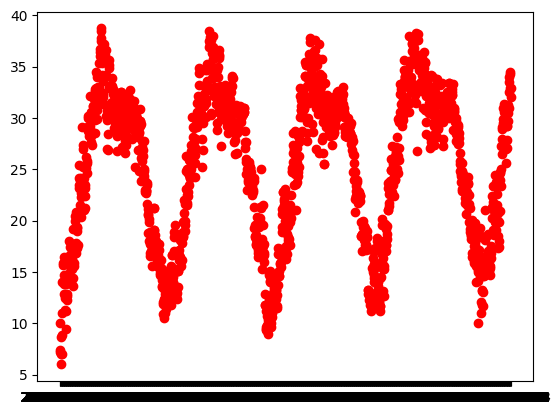

In [24]:
plt.scatter(df['date'],df['meantemp'],color='red')

In [42]:
x1 = df['meantemp'].ewm(alpha=0.9).mean()

In [43]:
x1

0       10.000000
1        7.636364
2        7.213213
3        8.521452
4        6.252123
          ...    
1571    34.403401
1572    34.265340
1573    33.036534
1574    32.891153
1575    32.089115
Name: meantemp, Length: 1576, dtype: float64

In [44]:
df['ewma'] = x1

In [45]:
df

,date,meantemp,ewma
0,2013-01-01,10.000000,10.000000
1,2013-01-02,7.400000,7.636364
2,2013-01-03,7.166667,7.213213
3,2013-01-04,8.666667,8.521452
4,2013-01-05,6.000000,6.252123
...,...,...,...
1571,2017-04-20,34.500000,34.403401
1572,2017-04-21,34.250000,34.265340
1573,2017-04-22,32.900000,33.036534
1574,2017-04-23,32.875000,32.891153


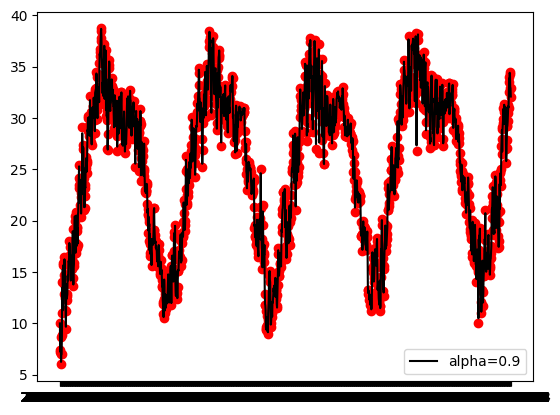

In [46]:
plt.scatter(df['date'],df['meantemp'],color='red')
plt.plot(df['date'],x1,color='black',label='alpha=0.9')
plt.legend()
plt.show()